In [1]:
import numpy as np
import sys, os

In [ ]:
"""
Created on Sat Sep 25 09:12:46 2021
Prepare gauge locations for mHM based on flow accumulation raster and DEM

@author: cuneyd
"""

In [ ]:
morph_dir = r'E:\VUB\_data\mhm_EastAfrica\subset_EA'

### Original method
Manual header entry.  
Make sure the header values are correct. I have made a mistake here before

In [3]:

def writeFACCtr(arrayy):

    header = """\
ncols        11264
nrows        13056
xllcorner    29.000000000000
yllcorner    -5.50000000000
cellsize     0.001953125000
NODATA_value -9999
"""
        
    np.savetxt('array.txt', np.array(arrayy, ndmin=1, copy=False),fmt='%4.0f', delimiter=" ")
    
    with open(morph_dir + '/idgauges_NEW.asc','w') as outfile:
             outfile.write(header)
             with open('array.txt','r') as datafile:
                  for line in datafile:
                      outfile.write(line)
                      
    os.remove("array.txt")   
    print('Map written')

#== read flow accumulation and DEM rasters======================================================

facc = np.loadtxt(morph_dir + '/facc.asc',skiprows=6)
dem = np.loadtxt(morph_dir + '/dem.asc',skiprows=6)


gage_13000=np.argwhere((facc==36280)&(dem==1903))
gage_13001=np.argwhere((facc==32670)&(dem==1789))
gage_13049=np.argwhere((facc==17961)&(dem==1888))
gage_13031=np.argwhere((facc==61690)&(dem==1154))

#set all to 0 and then assign gauge ids to the corresponding locations
facc[:] = 0
# facc[facc>=0] = 0;


facc[gage_13000[0,0],gage_13000[0,1]] = 13000;
facc[gage_13001[0,0],gage_13001[0,1]] = 13001;
facc[gage_13049[0,0],gage_13049[0,1]] = 13049;
facc[gage_13031[0,0],gage_13031[0,1]] = 13031;

writeFACCtr(facc)

#data[data>=0] = -9999;
#data[data==-1]= 16003;

#realdata=np.argwhere(data>0)
#
#data(data>=0) = -9999;
#data(data==-1) = 16003;

Map written


### Auto method
header read from files.

In [ ]:
def writeFACCtr(arrayy):

    # read correct header from an existing reference grid
    with open(morph_dir + "/facc.asc", "r") as f:
        header = [next(f) for _ in range(6)]

    with open(morph_dir + "/idgauges_NEW.asc", "w") as outfile:
        outfile.writelines(header)
        np.savetxt(outfile, np.array(arrayy, ndmin=2, copy=False), fmt="%4.0f", delimiter=" ")

    print("Map written")


#== read flow accumulation and DEM rasters =====================================================

facc = np.loadtxt(morph_dir + "/facc.asc", skiprows=6)
dem  = np.loadtxt(morph_dir + "/dem.asc",  skiprows=6)

gage_13031 = np.argwhere((facc == 61690) & (dem == 1154))
gage_13081 = np.argwhere((facc ==  7675) & (dem == 1906))
gage_13049 = np.argwhere((facc == 17961) & (dem == 1888))

# set all to 0 and then assign gauge ids
facc[:] = 0

facc[gage_13031[0,0], gage_13031[0,1]] = 13031
facc[gage_13081[0,0], gage_13081[0,1]] = 13081
facc[gage_13049[0,0], gage_13049[0,1]] = 13049

writeFACCtr(facc)


In [ ]:
paths = [
    morph_dir+"/facc.asc",
    morph_dir+"/idgauges_NEW.asc",
    morph_dir+"/dem.asc",          
    # add other inputs mHM reads around that step if needed
]

for p in paths:
    print("\n---", p, "---")
    with open(p, "r") as f:
        for _ in range(6):
            print(f.readline().strip())


In [1]:
import pandas as pd


In [2]:
q=pd.read_csv("daily_discharge.out", sep='\s+')

In [3]:
q.columns

Index(['No', 'Day', 'Mon', 'Year', 'Qobs_0000013000', 'Qsim_0000013000',
       'Qobs_0000013001', 'Qsim_0000013001', 'Qobs_0000013049',
       'Qsim_0000013049', 'Qobs_0000013031', 'Qsim_0000013031'],
      dtype='object')

<Axes: >

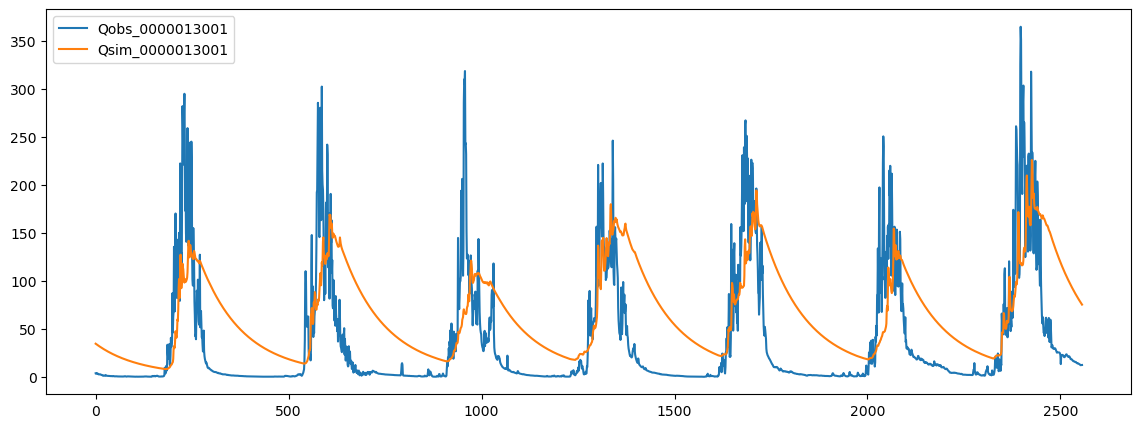

In [8]:
q[['Qobs_0000013001','Qsim_0000013001']].plot(figsize=(14,5))